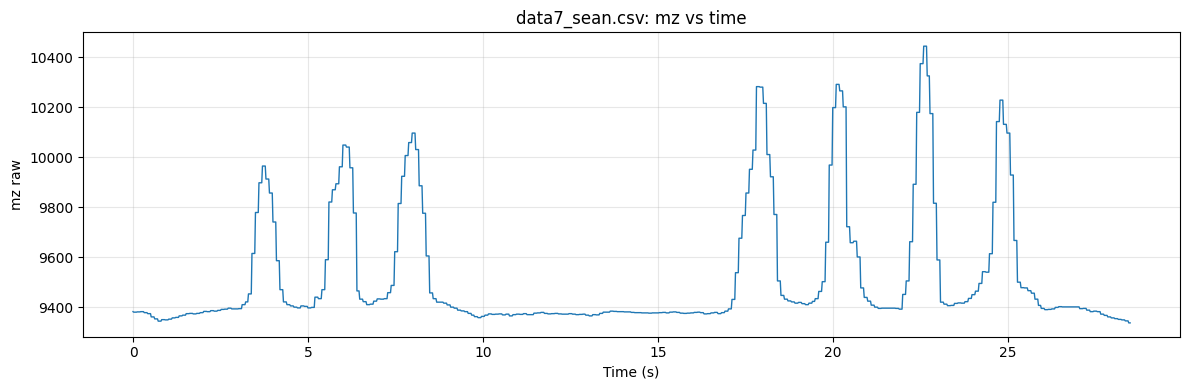

In [125]:
# data7_sean.csv: timestamp vs mz only
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

path = Path("data7_sean.csv")
rows = []
with path.open() as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split(",")
        if len(parts) < 5:
            continue
        rows.append({
            "timestamp_ms": float(parts[1]),
            "mz": float(parts[4]),
        })

df7 = pd.DataFrame(rows)
df7["time_s"] = (df7["timestamp_ms"] - df7["timestamp_ms"].iloc[0]) / 1000.0

plt.figure(figsize=(12, 4))
plt.plot(df7["time_s"], df7["mz"], linewidth=1.0)
plt.xlabel("Time (s)")
plt.ylabel("mz raw")
plt.title("data7_sean.csv: mz vs time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


""


startup b0 = 9365.53, events = 0


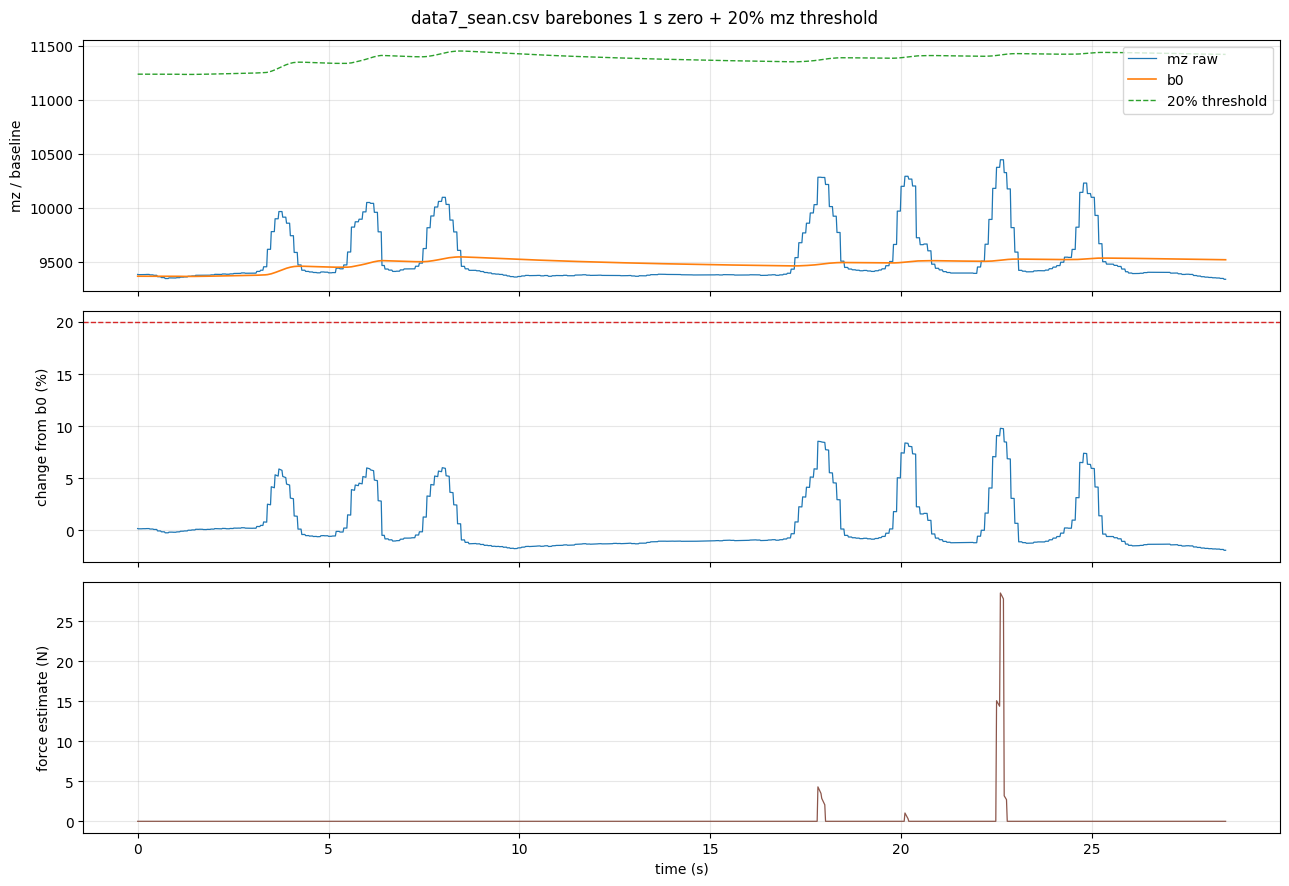

In [126]:
# Barebones zeroing detector for data7_sean.csv
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CSV_PATH = Path("data7_sean.csv")
STARTUP_ZERO_S = 1.0
THRESHOLD_FRAC = 0.20
REFRACTORY_MS = 50.0
SUSTAINED_CUTOFF_S = 2.0
FORCE_SLOPE = 658.7
FORCE_INTERCEPT = -173.5
BASELINE_DISTANCE_MM = 10.0

rows = []
with CSV_PATH.open() as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split(",")
        if len(parts) < 5:
            continue
        rows.append({
            "seq": int(parts[0]),
            "timestamp_ms": float(parts[1]),
            "mx": float(parts[2]),
            "my": float(parts[3]),
            "mz": float(parts[4]),
        })

df = pd.DataFrame(rows)
df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
df["abs_mz"] = df["mz"].abs()

startup = df[df["time_s"] <= STARTUP_ZERO_S]
b0 = startup["abs_mz"].mean()
threshold = b0 * (1.0 + THRESHOLD_FRAC)

state = "idle"
baseline_samples = []
load_start_t = None
last_release_t = -1e9
events = []

states = []
baselines = []
dev_fracs = []
r_diffs = []
forces = []

for row in df.itertuples(index=False):
    t = row.time_s
    abs_mz = row.abs_mz
    dev_frac = (abs_mz - b0) / b0 if b0 else 0.0

    r_diff = 0.0
    if abs_mz > 1.0 and b0 > 1.0 and abs_mz > b0:
        r_mm = BASELINE_DISTANCE_MM * (b0 / abs_mz) ** (1.0 / 3.0)
        r_diff = BASELINE_DISTANCE_MM - r_mm
    force_n = max(FORCE_SLOPE * r_diff + FORCE_INTERCEPT, 0.0) if r_diff > 0 else 0.0

    if state == "idle":
        can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
        if can_start and abs_mz >= threshold:
            state = "loaded"
            load_start_t = t
            baseline_samples = []
        else:
            baseline_samples.append(abs_mz)
            if t > STARTUP_ZERO_S and baseline_samples:
                b0 = sum(baseline_samples) / len(baseline_samples)
                threshold = b0 * (1.0 + THRESHOLD_FRAC)

    elif state == "loaded":
        if abs_mz < threshold:
            duration_s = t - load_start_t
            # Literal version of your note: releases before 2 s are labelled sustained.
            kind = "sustained" if duration_s < SUSTAINED_CUTOFF_S else "long_load"
            events.append({
                "start_s": load_start_t,
                "end_s": t,
                "duration_s": duration_s,
                "kind": kind,
            })
            state = "idle"
            last_release_t = t
            baseline_samples = [abs_mz]
            b0 = abs_mz
            threshold = b0 * (1.0 + THRESHOLD_FRAC)

    states.append(state)
    baselines.append(b0)
    dev_fracs.append(dev_frac)
    r_diffs.append(r_diff)
    forces.append(force_n)

df["state"] = states
df["b0"] = baselines
df["threshold"] = [b * (1.0 + THRESHOLD_FRAC) for b in baselines]
df["dev_frac"] = dev_fracs
df["r_diff_mm"] = r_diffs
df["force_n"] = forces

events_df = pd.DataFrame(events)
display(events_df)
print(f"startup b0 = {startup['abs_mz'].mean():.2f}, events = {len(events_df)}")

fig, axs = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axs[0].plot(df["time_s"], df["mz"], lw=0.9, label="mz raw")
axs[0].plot(df["time_s"], df["b0"], lw=1.2, label="b0")
axs[0].plot(df["time_s"], df["threshold"], lw=1.0, ls="--", label="20% threshold")
axs[0].set_ylabel("mz / baseline")
axs[0].legend(loc="upper right")
axs[0].grid(True, alpha=0.3)

axs[1].plot(df["time_s"], df["dev_frac"] * 100.0, lw=0.9)
axs[1].axhline(THRESHOLD_FRAC * 100.0, color="C3", ls="--", lw=1.0)
axs[1].set_ylabel("change from b0 (%)")
axs[1].grid(True, alpha=0.3)

axs[2].plot(df["time_s"], df["force_n"], lw=0.9, color="C5")
axs[2].set_ylabel("force estimate (N)")
axs[2].set_xlabel("time (s)")
axs[2].grid(True, alpha=0.3)

for event in events:
    color = "C2" if event["kind"] == "sustained" else "C1"
    for ax in axs:
        ax.axvspan(event["start_s"], event["end_s"], color=color, alpha=0.15)

fig.suptitle("data7_sean.csv barebones 1 s zero + 20% mz threshold")
plt.tight_layout()
plt.show()


,start_s,end_s,duration_s,kind
0,3.42,4.34,0.92,step
1,5.54,6.54,1.00,step
2,7.50,8.58,1.08,step
3,17.24,18.76,1.52,step
4,19.84,20.88,1.04,step
5,22.14,23.22,1.08,step
6,24.62,25.30,0.68,step


startup mean=9351.30, startup std=13.97, events=7, steps=7, sustained=0


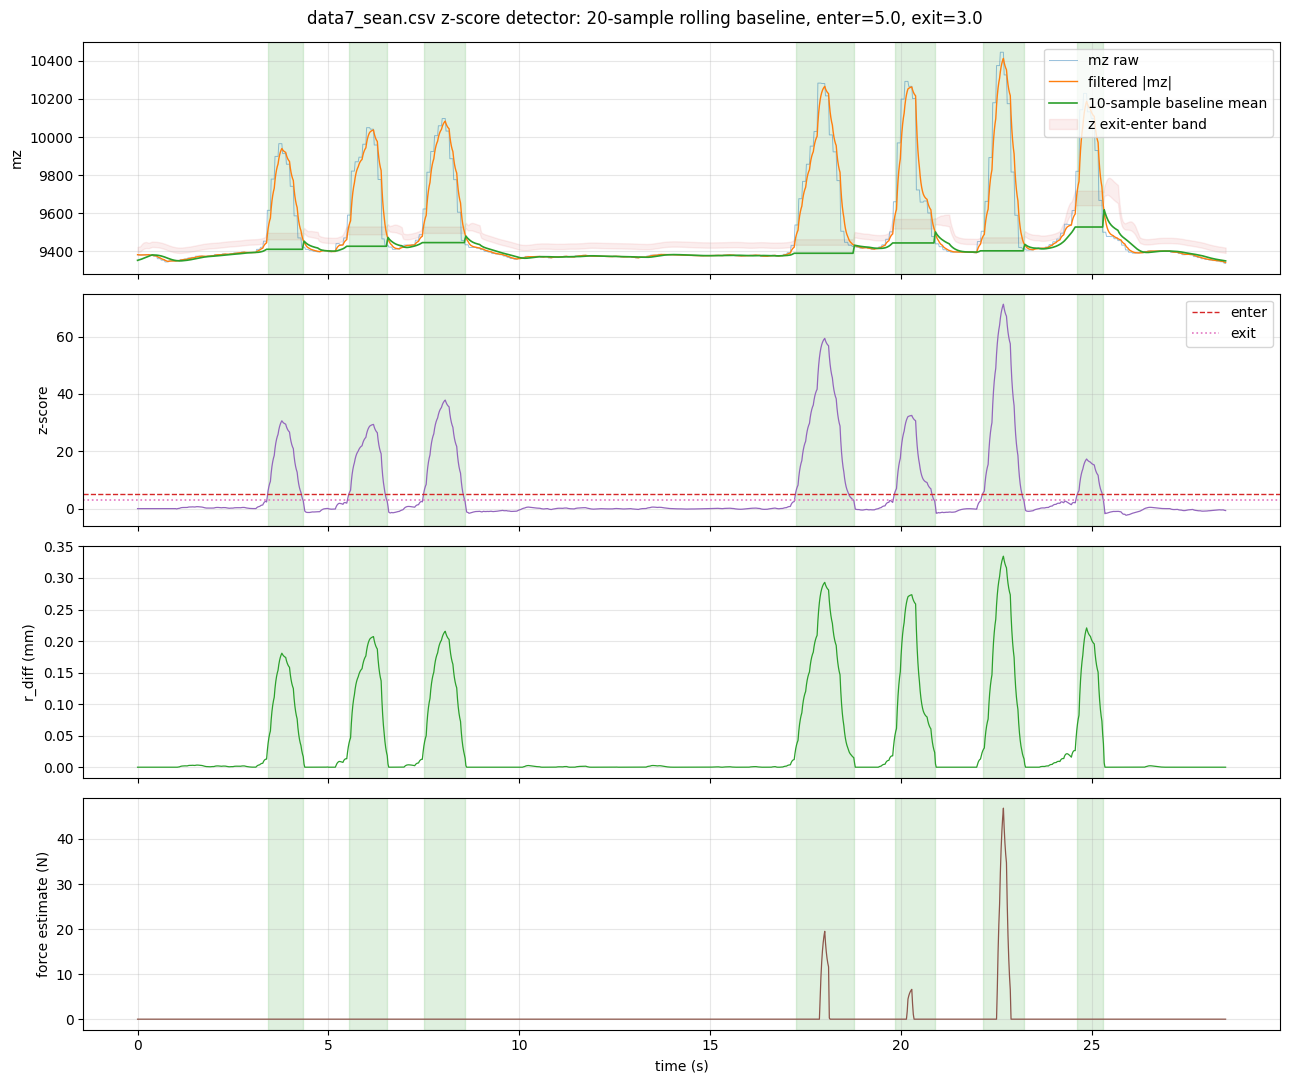

In [127]:
# Z-score detector experiment for data7_sean.csv with 10-sample rolling baseline
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CSV_PATH = Path("data7_sean.csv")
STARTUP_ZERO_S = 1.0
BASELINE_WINDOW_SAMPLES = 20
Z_ENTER = 5.0
Z_EXIT = 3.0
REFRACTORY_MS = 50.0
SUSTAINED_CUTOFF_S = 2.0
MAG_LPF_ALPHA = 0.25
STD_FLOOR = 1.0
FORCE_SLOPE = 658.7
FORCE_INTERCEPT = -173.5
BASELINE_DISTANCE_MM = 10.0

rows = []
with CSV_PATH.open() as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split(",")
        if len(parts) < 5:
            continue
        rows.append({
            "seq": int(parts[0]),
            "timestamp_ms": float(parts[1]),
            "mz": float(parts[4]),
        })

df = pd.DataFrame(rows)
df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
df["abs_mz"] = df["mz"].abs()
df["abs_mz_lpf"] = df["abs_mz"].ewm(alpha=MAG_LPF_ALPHA, adjust=False).mean()

startup = df[df["time_s"] <= STARTUP_ZERO_S]
startup_std_floor = max(startup["abs_mz_lpf"].std(ddof=1), STD_FLOOR)
baseline_window = deque(startup["abs_mz_lpf"].tail(BASELINE_WINDOW_SAMPLES), maxlen=BASELINE_WINDOW_SAMPLES)


def window_stats(window):
    vals = pd.Series(list(window), dtype="float64")
    mean = vals.mean()
    std = vals.std(ddof=1) if len(vals) > 1 else STD_FLOOR
    # Keep the rolling mean responsive, but do not let z-score noise scale collapse.
    return mean, max(std, startup_std_floor)


def update_rolling_baseline(window, b):
    window.append(b)
    return window_stats(window)


baseline_mean, baseline_std = window_stats(baseline_window)
startup_mean = baseline_mean
startup_std = baseline_std

state = "idle"
load_start_t = None
last_release_t = -1e9
events = []

states = []
baseline_means = []
baseline_stds = []
z_scores = []
r_diffs = []
forces = []

for row in df.itertuples(index=False):
    t = row.time_s
    b = row.abs_mz_lpf

    # During startup, keep filling the same 10-sample rolling window.
    if t <= STARTUP_ZERO_S:
        baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
        z = 0.0
        r_diff = 0.0
        force_n = 0.0
        states.append("zeroing")
        baseline_means.append(baseline_mean)
        baseline_stds.append(baseline_std)
        z_scores.append(z)
        r_diffs.append(r_diff)
        forces.append(force_n)
        continue

    z = (b - baseline_mean) / max(baseline_std, STD_FLOOR)

    r_diff = 0.0
    if b > 1.0 and baseline_mean > 1.0 and b > baseline_mean:
        r_mm = BASELINE_DISTANCE_MM * (baseline_mean / b) ** (1.0 / 3.0)
        r_diff = BASELINE_DISTANCE_MM - r_mm
    force_n = max(FORCE_SLOPE * r_diff + FORCE_INTERCEPT, 0.0) if r_diff > 0 else 0.0

    if state == "idle":
        can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
        if can_start and z >= Z_ENTER:
            state = "loaded"
            load_start_t = t
        elif abs(z) < Z_EXIT:
            # Only quiet unloaded samples are allowed to teach the baseline.
            baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
        else:
            # Suspicious movement: freeze baseline so the rising edge cannot be learned away.
            pass

    elif state == "loaded":
        if z <= Z_EXIT:
            duration_s = t - load_start_t
            kind = "step" if duration_s < SUSTAINED_CUTOFF_S else "sustained"
            events.append({
                "start_s": load_start_t,
                "end_s": t,
                "duration_s": duration_s,
                "kind": kind,
            })

            old_mean = baseline_mean
            baseline_window.clear()
            baseline_window.append(b)
            new_window_mean, new_window_std = window_stats(baseline_window)
            baseline_mean = 0.5 * (old_mean + new_window_mean)
            baseline_std = max(0.5 * (baseline_std + new_window_std), STD_FLOOR)

            state = "idle"
            last_release_t = t
            load_start_t = None

    states.append(state)
    baseline_means.append(baseline_mean)
    baseline_stds.append(baseline_std)
    z_scores.append(z)
    r_diffs.append(r_diff)
    forces.append(force_n)

df["state"] = states
df["baseline_mean"] = baseline_means
df["baseline_std"] = baseline_stds
df["z_score"] = z_scores
df["r_diff_mm"] = r_diffs
df["force_n"] = forces

events_df = pd.DataFrame(events)
display(events_df)
print(
    f"startup mean={startup_mean:.2f}, startup std={startup_std:.2f}, "
    f"events={len(events_df)}, steps={(events_df['kind'] == 'step').sum() if len(events_df) else 0}, "
    f"sustained={(events_df['kind'] == 'sustained').sum() if len(events_df) else 0}"
)

fig, axs = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

axs[0].plot(df["time_s"], df["mz"], lw=0.7, alpha=0.45, label="mz raw")
axs[0].plot(df["time_s"], df["abs_mz_lpf"], lw=1.0, label="filtered |mz|")
axs[0].plot(df["time_s"], df["baseline_mean"], lw=1.2, label="10-sample baseline mean")
axs[0].fill_between(
    df["time_s"],
    df["baseline_mean"] + Z_EXIT * df["baseline_std"],
    df["baseline_mean"] + Z_ENTER * df["baseline_std"],
    color="C3",
    alpha=0.08,
    label="z exit-enter band",
)
axs[0].set_ylabel("mz")
axs[0].legend(loc="upper right")
axs[0].grid(True, alpha=0.3)

axs[1].plot(df["time_s"], df["z_score"], lw=0.9, color="C4")
axs[1].axhline(Z_ENTER, color="C3", ls="--", lw=1.0, label="enter")
axs[1].axhline(Z_EXIT, color="C6", ls=":", lw=1.2, label="exit")
axs[1].set_ylabel("z-score")
axs[1].legend(loc="upper right")
axs[1].grid(True, alpha=0.3)

axs[2].plot(df["time_s"], df["r_diff_mm"], lw=0.9, color="C2")
axs[2].set_ylabel("r_diff (mm)")
axs[2].grid(True, alpha=0.3)

axs[3].plot(df["time_s"], df["force_n"], lw=0.9, color="C5")
axs[3].set_ylabel("force estimate (N)")
axs[3].set_xlabel("time (s)")
axs[3].grid(True, alpha=0.3)

for event in events:
    color = "C2" if event["kind"] == "step" else "C1"
    for ax in axs:
        ax.axvspan(event["start_s"], event["end_s"], color=color, alpha=0.15)

fig.suptitle(f"data7_sean.csv z-score detector: {BASELINE_WINDOW_SAMPLES}-sample rolling baseline, enter={Z_ENTER}, exit={Z_EXIT}")
plt.tight_layout()
plt.show()


,start_s,end_s,duration_s,kind
0,4.22,5.76,1.54,step
1,7.24,8.42,1.18,step
2,9.74,10.64,0.90,step
3,15.06,16.86,1.80,step
4,17.60,18.78,1.18,step
5,20.38,21.54,1.16,step
6,25.90,27.26,1.36,step
7,27.98,29.28,1.30,step
8,30.62,31.56,0.94,step
9,32.74,33.78,1.04,step


startup mean=9365.14, startup std=8.56, events=12, steps=12, sustained=0


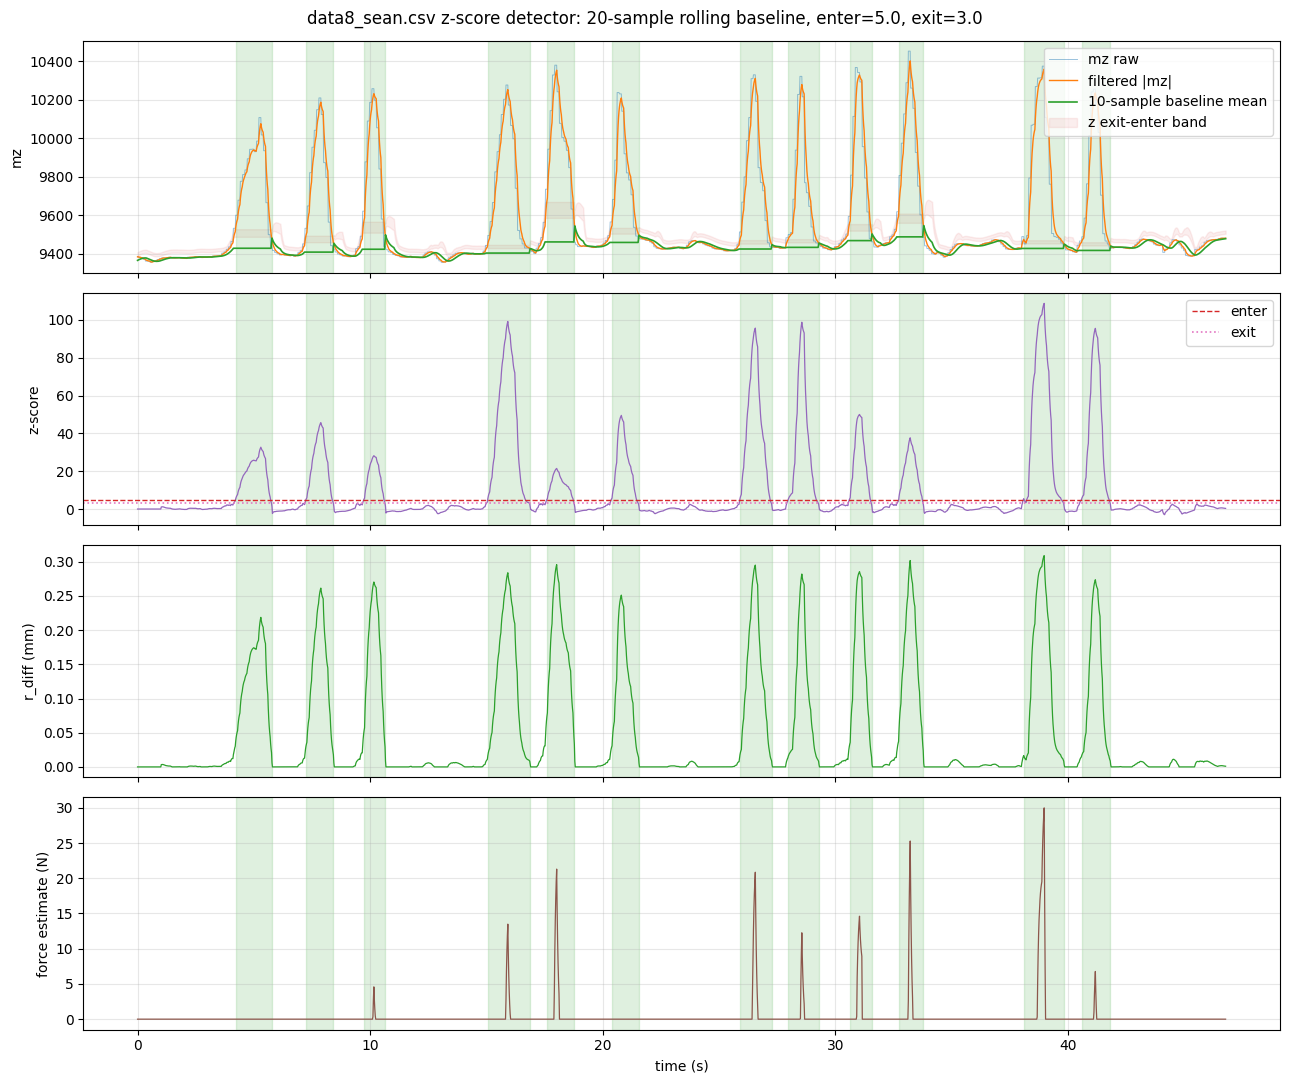

In [128]:
# Z-score detector experiment for data8_sean.csv with same analysis
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CSV_PATH = Path("data8_sean.csv")
STARTUP_ZERO_S = 1.0
BASELINE_WINDOW_SAMPLES = 20
Z_ENTER = 5.0
Z_EXIT = 3.0
REFRACTORY_MS = 50.0
SUSTAINED_CUTOFF_S = 2.0
MAG_LPF_ALPHA = 0.25
STD_FLOOR = 1.0
FORCE_SLOPE = 658.7
FORCE_INTERCEPT = -173.5
BASELINE_DISTANCE_MM = 10.0

rows = []
with CSV_PATH.open() as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split(",")
        if len(parts) < 5:
            continue
        try:
            rows.append({
                "seq": int(parts[0]),
                "timestamp_ms": float(parts[1]),
                "mz": float(parts[4]),
            })
        except ValueError:
            continue

df = pd.DataFrame(rows)
df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
df["abs_mz"] = df["mz"].abs()
df["abs_mz_lpf"] = df["abs_mz"].ewm(alpha=MAG_LPF_ALPHA, adjust=False).mean()

startup = df[df["time_s"] <= STARTUP_ZERO_S]
startup_std_floor = max(startup["abs_mz_lpf"].std(ddof=1), STD_FLOOR)
baseline_window = deque(startup["abs_mz_lpf"].tail(BASELINE_WINDOW_SAMPLES), maxlen=BASELINE_WINDOW_SAMPLES)


def window_stats(window):
    vals = pd.Series(list(window), dtype="float64")
    mean = vals.mean()
    std = vals.std(ddof=1) if len(vals) > 1 else STD_FLOOR
    # Keep the rolling mean responsive, but do not let z-score noise scale collapse.
    return mean, max(std, startup_std_floor)


def update_rolling_baseline(window, b):
    window.append(b)
    return window_stats(window)


baseline_mean, baseline_std = window_stats(baseline_window)
startup_mean = baseline_mean
startup_std = baseline_std

state = "idle"
load_start_t = None
last_release_t = -1e9
events = []

states = []
baseline_means = []
baseline_stds = []
z_scores = []
r_diffs = []
forces = []

for row in df.itertuples(index=False):
    t = row.time_s
    b = row.abs_mz_lpf

    # During startup, keep filling the same 10-sample rolling window.
    if t <= STARTUP_ZERO_S:
        baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
        z = 0.0
        r_diff = 0.0
        force_n = 0.0
        states.append("zeroing")
        baseline_means.append(baseline_mean)
        baseline_stds.append(baseline_std)
        z_scores.append(z)
        r_diffs.append(r_diff)
        forces.append(force_n)
        continue

    z = (b - baseline_mean) / max(baseline_std, STD_FLOOR)

    r_diff = 0.0
    if b > 1.0 and baseline_mean > 1.0 and b > baseline_mean:
        r_mm = BASELINE_DISTANCE_MM * (baseline_mean / b) ** (1.0 / 3.0)
        r_diff = BASELINE_DISTANCE_MM - r_mm
    force_n = max(FORCE_SLOPE * r_diff + FORCE_INTERCEPT, 0.0) if r_diff > 0 else 0.0

    if state == "idle":
        can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
        if can_start and z >= Z_ENTER:
            state = "loaded"
            load_start_t = t
        elif abs(z) < Z_EXIT:
            # Only quiet unloaded samples are allowed to teach the baseline.
            baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
        else:
            # Suspicious movement: freeze baseline so the rising edge cannot be learned away.
            pass

    elif state == "loaded":
        if z <= Z_EXIT:
            duration_s = t - load_start_t
            kind = "step" if duration_s < SUSTAINED_CUTOFF_S else "sustained"
            events.append({
                "start_s": load_start_t,
                "end_s": t,
                "duration_s": duration_s,
                "kind": kind,
            })

            old_mean = baseline_mean
            baseline_window.clear()
            baseline_window.append(b)
            new_window_mean, new_window_std = window_stats(baseline_window)
            baseline_mean = 0.5 * (old_mean + new_window_mean)
            baseline_std = max(0.5 * (baseline_std + new_window_std), STD_FLOOR)

            state = "idle"
            last_release_t = t
            load_start_t = None

    states.append(state)
    baseline_means.append(baseline_mean)
    baseline_stds.append(baseline_std)
    z_scores.append(z)
    r_diffs.append(r_diff)
    forces.append(force_n)

df["state"] = states
df["baseline_mean"] = baseline_means
df["baseline_std"] = baseline_stds
df["z_score"] = z_scores
df["r_diff_mm"] = r_diffs
df["force_n"] = forces

events_df = pd.DataFrame(events)
display(events_df)
print(
    f"startup mean={startup_mean:.2f}, startup std={startup_std:.2f}, "
    f"events={len(events_df)}, steps={(events_df['kind'] == 'step').sum() if len(events_df) else 0}, "
    f"sustained={(events_df['kind'] == 'sustained').sum() if len(events_df) else 0}"
)

fig, axs = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

axs[0].plot(df["time_s"], df["mz"], lw=0.7, alpha=0.45, label="mz raw")
axs[0].plot(df["time_s"], df["abs_mz_lpf"], lw=1.0, label="filtered |mz|")
axs[0].plot(df["time_s"], df["baseline_mean"], lw=1.2, label="10-sample baseline mean")
axs[0].fill_between(
    df["time_s"],
    df["baseline_mean"] + Z_EXIT * df["baseline_std"],
    df["baseline_mean"] + Z_ENTER * df["baseline_std"],
    color="C3",
    alpha=0.08,
    label="z exit-enter band",
)
axs[0].set_ylabel("mz")
axs[0].legend(loc="upper right")
axs[0].grid(True, alpha=0.3)

axs[1].plot(df["time_s"], df["z_score"], lw=0.9, color="C4")
axs[1].axhline(Z_ENTER, color="C3", ls="--", lw=1.0, label="enter")
axs[1].axhline(Z_EXIT, color="C6", ls=":", lw=1.2, label="exit")
axs[1].set_ylabel("z-score")
axs[1].legend(loc="upper right")
axs[1].grid(True, alpha=0.3)

axs[2].plot(df["time_s"], df["r_diff_mm"], lw=0.9, color="C2")
axs[2].set_ylabel("r_diff (mm)")
axs[2].grid(True, alpha=0.3)

axs[3].plot(df["time_s"], df["force_n"], lw=0.9, color="C5")
axs[3].set_ylabel("force estimate (N)")
axs[3].set_xlabel("time (s)")
axs[3].grid(True, alpha=0.3)

for event in events:
    color = "C2" if event["kind"] == "step" else "C1"
    for ax in axs:
        ax.axvspan(event["start_s"], event["end_s"], color=color, alpha=0.15)

fig.suptitle(f"data8_sean.csv z-score detector: {BASELINE_WINDOW_SAMPLES}-sample rolling baseline, enter={Z_ENTER}, exit={Z_EXIT}")
plt.tight_layout()
plt.show()


,file,events,steps,sustained,max_z
0,data_normal.csv,6,6,0,17.3
1,data2_start_stop.csv,8,6,2,15.6
2,data3_3stepsthenfall.csv,2,2,0,8.6
3,data4obstacles.csv,1,1,0,9.5
4,data5.csv,2,2,0,11.8
5,data6.csv,1,1,0,5.9
6,data7_sean.csv,7,7,0,71.3
7,data8_sean.csv,12,12,0,108.8
8,data9_sean_2_stops.csv,23,19,4,121.5


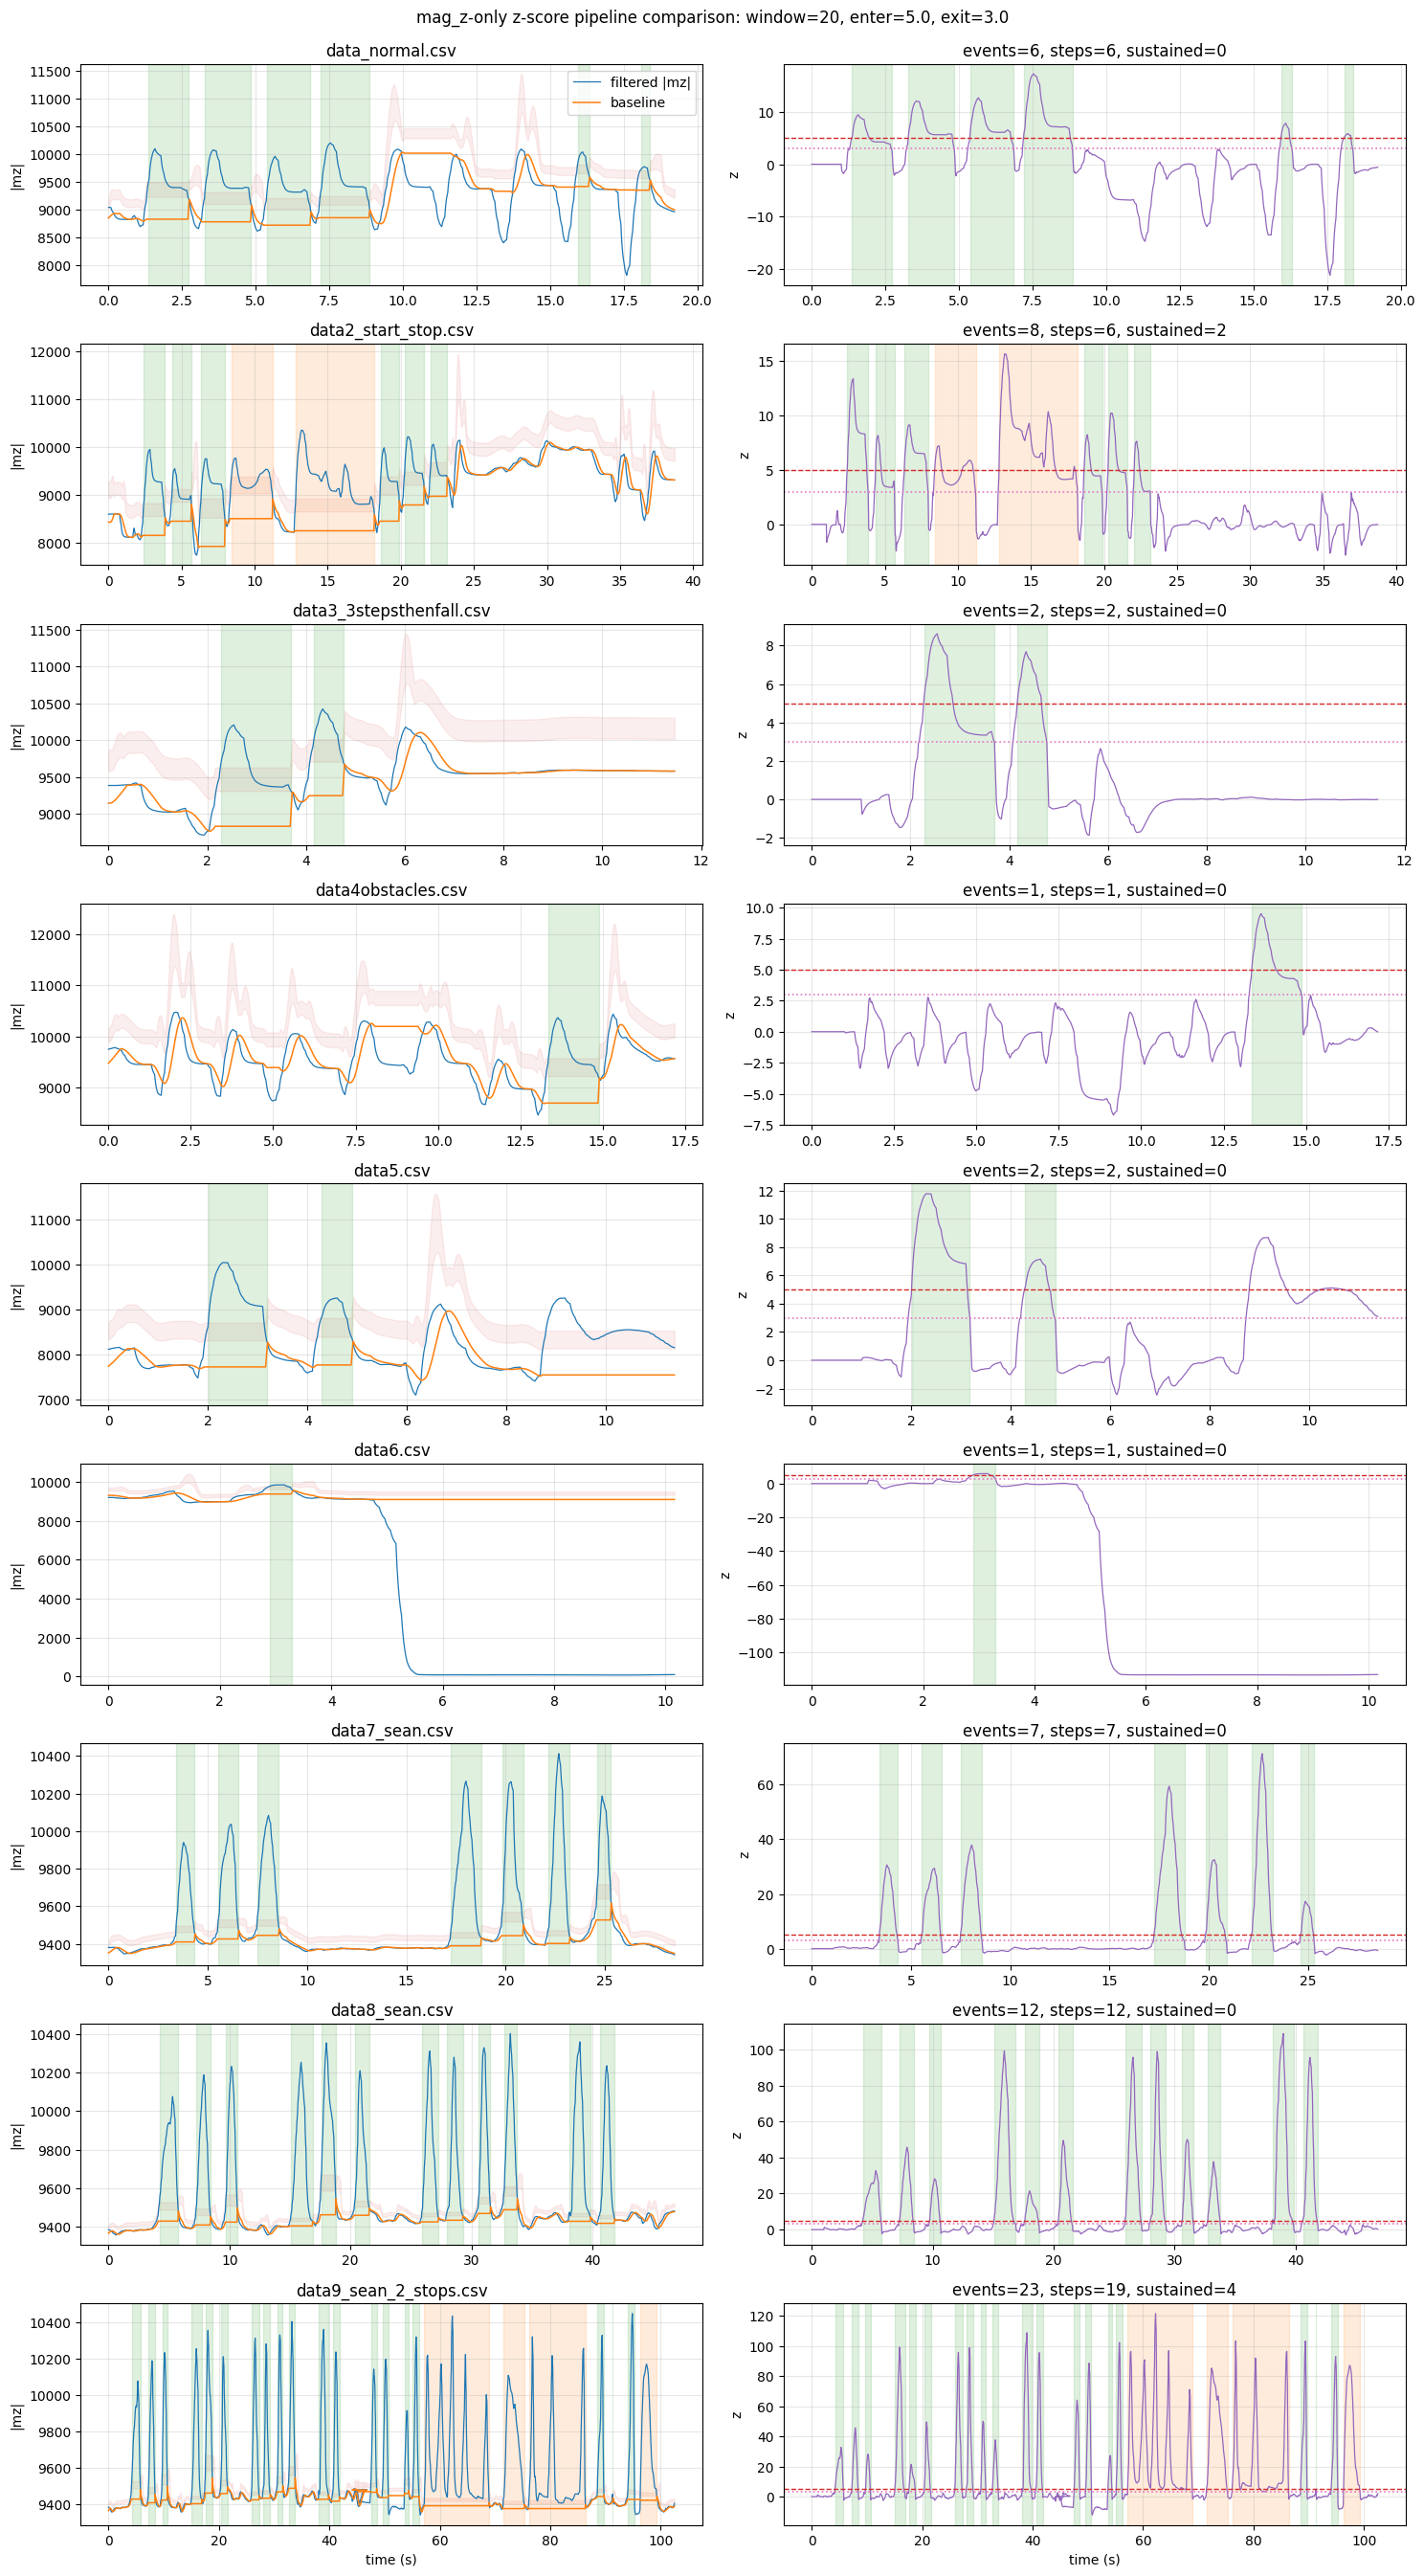

In [129]:
# Compare the current mag_z-only z-score pipeline across recordings
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CSV_FILES_COMPARE = [
    "data_normal.csv",
    "data2_start_stop.csv",
    "data3_3stepsthenfall.csv",
    "data4obstacles.csv",
    "data5.csv",
    "data6.csv",
    "data7_sean.csv",
    "data8_sean.csv",
    "data9_sean_2_stops.csv",
]

STARTUP_ZERO_S = 1.0
BASELINE_WINDOW_SAMPLES = 20
Z_ENTER = 5.0
Z_EXIT = 3.0
REFRACTORY_MS = 10
SUSTAINED_CUTOFF_S = 2.0
MAG_LPF_ALPHA = 0.25
STD_FLOOR = 1.0


def load_mz_csv(path):
    rows = []
    with Path(path).open() as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split(",")
            if len(parts) < 5:
                continue
            try:
                rows.append({
                    "seq": int(parts[0]),
                    "timestamp_ms": float(parts[1]),
                    "mz": float(parts[4]),
                })
            except ValueError:
                continue
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
    df["abs_mz"] = df["mz"].abs()
    df["abs_mz_lpf"] = df["abs_mz"].ewm(alpha=MAG_LPF_ALPHA, adjust=False).mean()
    return df


def run_z_pipeline(df):
    startup = df[df["time_s"] <= STARTUP_ZERO_S]
    startup_std_floor = max(startup["abs_mz_lpf"].std(ddof=1), STD_FLOOR)
    baseline_window = deque(startup["abs_mz_lpf"].tail(BASELINE_WINDOW_SAMPLES), maxlen=BASELINE_WINDOW_SAMPLES)

    def window_stats(window):
        vals = pd.Series(list(window), dtype="float64")
        mean = vals.mean()
        std = vals.std(ddof=1) if len(vals) > 1 else STD_FLOOR
        return mean, max(std, startup_std_floor)

    def update_rolling_baseline(window, b):
        window.append(b)
        return window_stats(window)

    baseline_mean, baseline_std = window_stats(baseline_window)
    state = "idle"
    load_start_t = None
    last_release_t = -1e9
    events = []

    states = []
    baseline_means = []
    baseline_stds = []
    z_scores = []

    for row in df.itertuples(index=False):
        t = row.time_s
        b = row.abs_mz_lpf

        if t <= STARTUP_ZERO_S:
            baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
            states.append("zeroing")
            baseline_means.append(baseline_mean)
            baseline_stds.append(baseline_std)
            z_scores.append(0.0)
            continue

        z = (b - baseline_mean) / max(baseline_std, STD_FLOOR)

        if state == "idle":
            can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
            if can_start and z >= Z_ENTER:
                state = "loaded"
                load_start_t = t
            elif abs(z) < Z_EXIT:
                baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)

        elif state == "loaded":
            if z <= Z_EXIT:
                duration_s = t - load_start_t
                kind = "step" if duration_s < SUSTAINED_CUTOFF_S else "sustained"
                events.append({
                    "start_s": load_start_t,
                    "end_s": t,
                    "duration_s": duration_s,
                    "kind": kind,
                })

                old_mean = baseline_mean
                old_std = baseline_std
                baseline_window.clear()
                baseline_window.append(b)
                new_window_mean, new_window_std = window_stats(baseline_window)
                baseline_mean = 0.5 * (old_mean + new_window_mean)
                baseline_std = max(0.5 * (old_std + new_window_std), STD_FLOOR)

                state = "idle"
                last_release_t = t
                load_start_t = None

        states.append(state)
        baseline_means.append(baseline_mean)
        baseline_stds.append(baseline_std)
        z_scores.append(z)

    out = df.copy()
    out["state"] = states
    out["baseline_mean"] = baseline_means
    out["baseline_std"] = baseline_stds
    out["z_score"] = z_scores
    return out, pd.DataFrame(events)


results = []
valid = []
for name in CSV_FILES_COMPARE:
    path = Path(name)
    if not path.exists():
        continue
    df_raw = load_mz_csv(path)
    if df_raw.empty:
        continue
    df_z, events_df = run_z_pipeline(df_raw)
    valid.append((name, df_z, events_df))
    results.append({
        "file": name,
        "events": len(events_df),
        "steps": int((events_df["kind"] == "step").sum()) if len(events_df) else 0,
        "sustained": int((events_df["kind"] == "sustained").sum()) if len(events_df) else 0,
        "max_z": round(float(df_z["z_score"].max()), 1),
    })

display(pd.DataFrame(results))

fig, axes = plt.subplots(len(valid), 2, figsize=(15, 3.0 * len(valid)), sharex=False)
if len(valid) == 1:
    axes = [axes]

for (name, df_z, events_df), (ax_mz, ax_z) in zip(valid, axes):
    ax_mz.plot(df_z["time_s"], df_z["abs_mz_lpf"], lw=0.9, label="filtered |mz|")
    ax_mz.plot(df_z["time_s"], df_z["baseline_mean"], lw=1.1, label="baseline")
    ax_mz.fill_between(
        df_z["time_s"],
        df_z["baseline_mean"] + Z_EXIT * df_z["baseline_std"],
        df_z["baseline_mean"] + Z_ENTER * df_z["baseline_std"],
        color="C3",
        alpha=0.08,
    )
    ax_mz.set_title(name)
    ax_mz.set_ylabel("|mz|")
    ax_mz.grid(True, alpha=0.3)

    ax_z.plot(df_z["time_s"], df_z["z_score"], lw=0.9, color="C4")
    ax_z.axhline(Z_ENTER, color="C3", ls="--", lw=1.0)
    ax_z.axhline(Z_EXIT, color="C6", ls=":", lw=1.2)
    ax_z.set_ylabel("z")
    ax_z.grid(True, alpha=0.3)

    for event in events_df.to_dict("records"):
        color = "C2" if event["kind"] == "step" else "C1"
        ax_mz.axvspan(event["start_s"], event["end_s"], color=color, alpha=0.15)
        ax_z.axvspan(event["start_s"], event["end_s"], color=color, alpha=0.15)

    ax_z.set_title(
        f"events={len(events_df)}, steps={int((events_df['kind'] == 'step').sum()) if len(events_df) else 0}, "
        f"sustained={int((events_df['kind'] == 'sustained').sum()) if len(events_df) else 0}"
    )

axes[-1][0].set_xlabel("time (s)")
axes[-1][1].set_xlabel("time (s)")
axes[0][0].legend(loc="upper right")
fig.suptitle(
    f"mag_z-only z-score pipeline comparison: window={BASELINE_WINDOW_SAMPLES}, enter={Z_ENTER}, exit={Z_EXIT}",
    y=0.995,
)
plt.tight_layout()
plt.show()


,start_s,end_s,duration_s,kind
0,4.22,5.76,1.54,step
1,7.24,8.42,1.18,step
2,9.74,10.64,0.90,step
3,15.06,16.86,1.80,step
4,17.60,18.78,1.18,step
5,20.38,21.54,1.16,step
6,25.90,27.26,1.36,step
7,27.98,29.28,1.30,step
8,30.62,31.56,0.94,step
9,32.74,33.78,1.04,step


startup mean=9365.14, startup std=8.56, events=23, steps=19, sustained=4


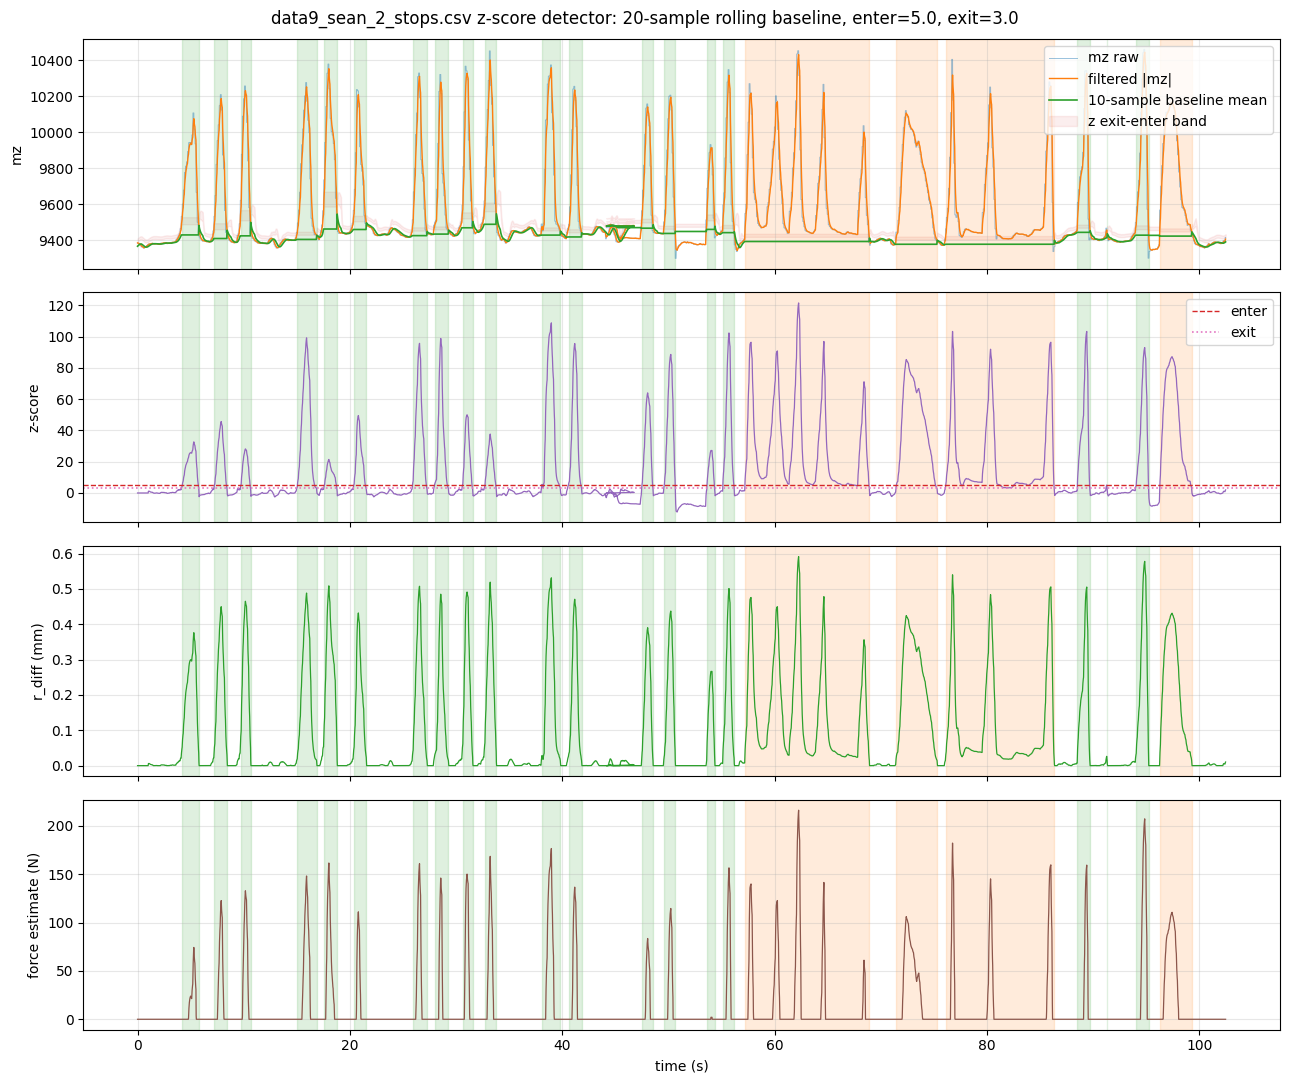

In [131]:
# Z-score detector experiment for data9_sean_2_stops.csv with same analysis
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CSV_PATH = Path("data9_sean_2_stops.csv")
STARTUP_ZERO_S = 1.0
BASELINE_WINDOW_SAMPLES = 20
Z_ENTER = 5.0
Z_EXIT = 3.0
REFRACTORY_MS = 50.0
SUSTAINED_CUTOFF_S = 2.0
MAG_LPF_ALPHA = 0.25
STD_FLOOR = 1.0
FORCE_SLOPE = 658.7
FORCE_INTERCEPT = -173.5
BASELINE_DISTANCE_MM = 17.2

rows = []
with CSV_PATH.open() as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split(",")
        if len(parts) < 5:
            continue
        try:
            rows.append({
                "seq": int(parts[0]),
                "timestamp_ms": float(parts[1]),
                "mz": float(parts[4]),
            })
        except ValueError:
            continue

df = pd.DataFrame(rows)
df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
df["abs_mz"] = df["mz"].abs()
df["abs_mz_lpf"] = df["abs_mz"].ewm(alpha=MAG_LPF_ALPHA, adjust=False).mean()

startup = df[df["time_s"] <= STARTUP_ZERO_S]
startup_std_floor = max(startup["abs_mz_lpf"].std(ddof=1), STD_FLOOR)
baseline_window = deque(startup["abs_mz_lpf"].tail(BASELINE_WINDOW_SAMPLES), maxlen=BASELINE_WINDOW_SAMPLES)


def window_stats(window):
    vals = pd.Series(list(window), dtype="float64")
    mean = vals.mean()
    std = vals.std(ddof=1) if len(vals) > 1 else STD_FLOOR
    # Keep the rolling mean responsive, but do not let z-score noise scale collapse.
    return mean, max(std, startup_std_floor)


def update_rolling_baseline(window, b):
    window.append(b)
    return window_stats(window)


baseline_mean, baseline_std = window_stats(baseline_window)
startup_mean = baseline_mean
startup_std = baseline_std

state = "idle"
load_start_t = None
last_release_t = -1e9
events = []

states = []
baseline_means = []
baseline_stds = []
z_scores = []
r_diffs = []
forces = []

for row in df.itertuples(index=False):
    t = row.time_s
    b = row.abs_mz_lpf

    # During startup, keep filling the same 10-sample rolling window.
    if t <= STARTUP_ZERO_S:
        baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
        z = 0.0
        r_diff = 0.0
        force_n = 0.0
        states.append("zeroing")
        baseline_means.append(baseline_mean)
        baseline_stds.append(baseline_std)
        z_scores.append(z)
        r_diffs.append(r_diff)
        forces.append(force_n)
        continue

    z = (b - baseline_mean) / max(baseline_std, STD_FLOOR)

    r_diff = 0.0
    if b > 1.0 and baseline_mean > 1.0 and b > baseline_mean:
        r_mm = BASELINE_DISTANCE_MM * (baseline_mean / b) ** (1.0 / 3.0)
        r_diff = BASELINE_DISTANCE_MM - r_mm
    force_n = max(FORCE_SLOPE * r_diff + FORCE_INTERCEPT, 0.0) if r_diff > 0 else 0.0

    if state == "idle":
        can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
        if can_start and z >= Z_ENTER:
            state = "loaded"
            load_start_t = t
        elif abs(z) < Z_EXIT:
            # Only quiet unloaded samples are allowed to teach the baseline.
            baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
        else:
            # Suspicious movement: freeze baseline so the rising edge cannot be learned away.
            pass

    elif state == "loaded":
        if z <= Z_EXIT:
            duration_s = t - load_start_t
            kind = "step" if duration_s < SUSTAINED_CUTOFF_S else "sustained"
            events.append({
                "start_s": load_start_t,
                "end_s": t,
                "duration_s": duration_s,
                "kind": kind,
            })

            old_mean = baseline_mean
            baseline_window.clear()
            baseline_window.append(b)
            new_window_mean, new_window_std = window_stats(baseline_window)
            baseline_mean = 0.5 * (old_mean + new_window_mean)
            baseline_std = max(0.5 * (baseline_std + new_window_std), STD_FLOOR)

            state = "idle"
            last_release_t = t
            load_start_t = None

    states.append(state)
    baseline_means.append(baseline_mean)
    baseline_stds.append(baseline_std)
    z_scores.append(z)
    r_diffs.append(r_diff)
    forces.append(force_n)

df["state"] = states
df["baseline_mean"] = baseline_means
df["baseline_std"] = baseline_stds
df["z_score"] = z_scores
df["r_diff_mm"] = r_diffs
df["force_n"] = forces

events_df = pd.DataFrame(events)
display(events_df)
print(
    f"startup mean={startup_mean:.2f}, startup std={startup_std:.2f}, "
    f"events={len(events_df)}, steps={(events_df['kind'] == 'step').sum() if len(events_df) else 0}, "
    f"sustained={(events_df['kind'] == 'sustained').sum() if len(events_df) else 0}"
)

fig, axs = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

axs[0].plot(df["time_s"], df["mz"], lw=0.7, alpha=0.45, label="mz raw")
axs[0].plot(df["time_s"], df["abs_mz_lpf"], lw=1.0, label="filtered |mz|")
axs[0].plot(df["time_s"], df["baseline_mean"], lw=1.2, label="10-sample baseline mean")
axs[0].fill_between(
    df["time_s"],
    df["baseline_mean"] + Z_EXIT * df["baseline_std"],
    df["baseline_mean"] + Z_ENTER * df["baseline_std"],
    color="C3",
    alpha=0.08,
    label="z exit-enter band",
)
axs[0].set_ylabel("mz")
axs[0].legend(loc="upper right")
axs[0].grid(True, alpha=0.3)

axs[1].plot(df["time_s"], df["z_score"], lw=0.9, color="C4")
axs[1].axhline(Z_ENTER, color="C3", ls="--", lw=1.0, label="enter")
axs[1].axhline(Z_EXIT, color="C6", ls=":", lw=1.2, label="exit")
axs[1].set_ylabel("z-score")
axs[1].legend(loc="upper right")
axs[1].grid(True, alpha=0.3)

axs[2].plot(df["time_s"], df["r_diff_mm"], lw=0.9, color="C2")
axs[2].set_ylabel("r_diff (mm)")
axs[2].grid(True, alpha=0.3)

axs[3].plot(df["time_s"], df["force_n"], lw=0.9, color="C5")
axs[3].set_ylabel("force estimate (N)")
axs[3].set_xlabel("time (s)")
axs[3].grid(True, alpha=0.3)

for event in events:
    color = "C2" if event["kind"] == "step" else "C1"
    for ax in axs:
        ax.axvspan(event["start_s"], event["end_s"], color=color, alpha=0.15)

fig.suptitle(f"data9_sean_2_stops.csv z-score detector: {BASELINE_WINDOW_SAMPLES}-sample rolling baseline, enter={Z_ENTER}, exit={Z_EXIT}")
plt.tight_layout()
plt.show()
